# Recreation of Mapping Algorithm from Phase -> Spatial

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import sys
from angular_spectrum_method import torch_propagate

In [28]:
class BitEncoder:
    def __init__(self):
        self.shifted_values = torch.arange(24)
        self.shifted_values = 1 << self.shifted_values

class Encode_Visible:
    def __init__(self):
        self.be = BitEncoder()
        self.m_plm_visible_logical_masks = torch.tensor([
            [[1, 0], [1, 0]],  
            [[1, 0], [0, 0]],  
            [[0, 0], [1, 0]],  
            [[1, 0], [1, 1]],  
            [[0, 0], [0, 0]],  
            [[1, 0], [0, 1]],  
            [[0, 0], [1, 1]],  
            [[0, 0], [0, 1]],  
            [[1, 1], [1, 0]],  
            [[1, 1], [0, 0]],  
            [[0, 1], [1, 0]],  
            [[0, 1], [0, 0]],  
            [[1, 1], [1, 1]],  
            [[1, 1], [0, 1]],  
            [[0, 1], [1, 1]],  
            [[0, 1], [0, 1]]   
        ], dtype=torch.float32)

    def encode(self, x : torch.Tensor):
        N = x.shape[0]
        input_h = x.shape[1]
        input_w = x.shape[2]

        logical = self.m_plm_visible_logical_masks[x]
        logical = logical.view(N, input_h, input_w, 2, 2)
        logical = logical.permute(0, 1, 3, 2, 4).contiguous()
        logical = logical.view(N, input_h * 2, input_w * 2)

        shifts_used = self.be.shifted_values[:N].to(logical.device).view(N, 1, 1)
        logical     = logical.to(torch.int32)
        logical     = torch.sum(logical * shifts_used, dim=0)
        logical     = torch.fliplr(logical)
        return logical
    
class Encode_NIR:
    def __init__(self):
        self.be = BitEncoder()
        self.m_plm_nir_logical_masks = torch.tensor([
            [
                [0, 0, 0], [0, 0, 0] 
            ],
            [
                [0, 0, 0], [0, 1, 0] 
            ],
            [
                [0, 1, 0], [0, 0, 0] 
            ],
            [
                [0, 1, 0], [0, 1, 0] 
            ],
            [
                [0, 0, 1], [1, 0, 0] 
            ],
            [
                [0, 0, 1], [1, 1, 0] 
            ],
            [
                [0, 1, 1], [1, 0, 0] 
            ],
            [
                [0, 1, 1], [1, 1, 0] 
            ],
            [
                [1, 0, 0], [0, 0, 0] 
            ],
            [
                [1, 0, 0], [0, 1, 0] 
            ],
            [
                [1, 1, 0], [0, 0, 0] 
            ],
            [
                [1, 1, 0], [0, 1, 0] 
            ],
            [
                [1, 0, 1], [1, 0, 0] 
            ],
            [
                [1, 0, 1], [1, 1, 0] 
            ],
            [
                [1, 1, 1], [1, 0, 0] 
            ],
            [
                [1, 1, 1], [1, 1, 0] 
            ],
            [
                [0, 0, 0], [0, 0, 1] 
            ],
            [
                [0, 0, 0], [0, 1, 1] 
            ],
            [
                [0, 1, 0], [0, 0, 1] 
            ],
            [
                [0, 1, 0], [0, 1, 1] 
            ],
            [
                [0, 0, 1], [1, 0, 1] 
            ],
            [
                [0, 0, 1], [1, 1, 1] 
            ],
            [
                [0, 1, 1], [1, 0, 1] 
            ],
            [
                [0, 1, 1], [1, 1, 1] 
            ],
            [
                [1, 0, 0], [0, 0, 1] 
            ],
            [
                [1, 0, 0], [1, 1, 0] 
            ],
            [
                [1, 1, 0], [0, 0, 1] 
            ],
            [
                [1, 1, 0], [0, 1, 1] 
            ],
            [
                [1, 0, 1], [1, 0 ,1] 
            ],
            [
                [1 ,0 ,1], [1 ,1 ,1] 
            ],
            [
                [1 ,1 ,1], [1 ,0 ,1] 
            ],
            [
                [1, 1, 1], [1, 1, 1] 
            ]
        ])

    def encode(self, x : torch.Tensor):
        N = x.shape[0]
        input_h = x.shape[1]
        input_w = x.shape[2]

        logical = self.m_plm_nir_logical_masks[x]
        logical = logical.view(N, input_h, input_w, 2, 3)
        logical = logical.permute(0, 1, 3, 2, 4).contiguous()
        logical = logical.view(N, input_h * 2, input_w * 3)

        shifts_used = self.be.shifted_values[:N].to(logical.device).view(N, 1, 1)
        logical     = logical.to(torch.int32)
        logical     = torch.sum(logical * shifts_used, dim=0)
        logical     = torch.fliplr(logical)

        # Zero padd left and
        # right side by 2 columns
        logical = torch.nn.functional.pad(logical, (2, 2), mode='constant', value=0)

        return logical


Input Tensor:
tensor([[[ 0,  1,  2,  3],
         [ 4,  5,  6,  7],
         [ 8,  9, 10, 11],
         [12, 13, 14, 15]]])


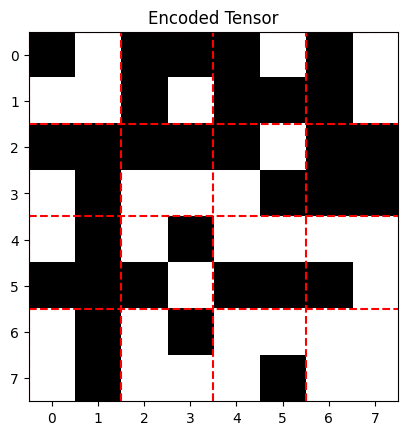

In [29]:
# Create a input tensor
# of shape (1, 4, 4)
# where values range from 0 to 15
x = torch.arange(16).reshape(1, 4, 4)
print("Input Tensor:")
print(x)

y = Encode_Visible().encode(x)

# visualize
plt.imshow(y.cpu().numpy(), cmap='gray')
plt.title("Encoded Tensor")

# draw lines to show the 2x2 blocks
for i in range(0, y.shape[0], 2):
    plt.axhline(i - 0.5, color='red', linestyle='--')
for j in range(0, y.shape[1], 2):
    plt.axvline(j - 0.5, color='red', linestyle='--')

plt.show()

Input Tensor:
tensor([[[ 0,  1,  2,  3,  4,  5,  6,  7],
         [ 8,  9, 10, 11, 12, 13, 14, 15],
         [16, 17, 18, 19, 20, 21, 22, 23],
         [24, 25, 26, 27, 28, 29, 30, 31]]])


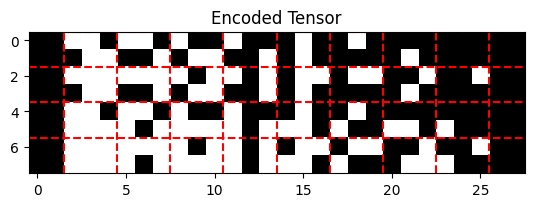

In [30]:
# Create a input tensor
# of values in range of 0 to 31

# reshape x into a 2d tensor of shape (1, 4, 8)
# where values range from 0 to 31
x = torch.arange(32).reshape(1, 4, 8)

print("Input Tensor:")
print(x)

y = Encode_NIR().encode(x)

# visualize
plt.imshow(y.cpu().numpy(), cmap='gray')
plt.title("Encoded Tensor")

# Account for the 2 columns of zero padding on left and right side
# by starting 2 columns in when drawing vertical lines
# draw lines to show the 2x3 blocks
for i in range(0, y.shape[0], 2):
    plt.axhline(i - 0.5, color='red', linestyle='--')
for j in range(2, y.shape[1], 3):
    plt.axvline(j - 0.5, color='red', linestyle='--')

plt.show()

In [44]:
# GS Algorithm for Free Space Propagation using torch_propagate
def GS_algorithm(Target: torch.Tensor, distance: float, num_iterations: int, 
                 wavelength: float = 1550e-9):
    """
    Gerchberg-Saxton algorithm for phase retrieval with free space propagation.
    Uses torch_propagate from angular_spectrum_method for propagation.
    
    Args:
        Target: Target intensity pattern [H, W]
        distance: Propagation distance in meters
        num_iterations: Number of GS iterations
        wavelength: Wavelength of light in meters (default: 1550nm)
        pixel_pitch: Pixel pitch in meters (default: 10.8um)
    
    Returns:
        phase: Computed phase pattern [H, W] in radians
        hologram: Complex field at hologram plane [H, W]
    """
    device = Target.device
    H, W = Target.shape
    
    # Calculate physical dimensions for torch_propagate
    Height = 800 * 10.8e-6
    Width  = 1358 * 10.8e-6
    
    # Normalize target amplitude
    target_amplitude = torch.sqrt(Target)
    target_amplitude = target_amplitude / target_amplitude.max()
    
    # Initialize with random phase at target plane
    phase_target = torch.rand(H, W, device=device) * 2 * np.pi
    field_target = target_amplitude * torch.exp(1j * phase_target)

    forward_cache = None
    backward_cache = None
    
    # GS iterations
    for iteration in range(num_iterations):
        # Propagate to hologram plane (backward in space: use negative distance)
        H1, forward_cache = torch_propagate(
            field_target, 
            z=distance,
            Height=Height,
            Width=Width,
            PixelH=H,
            PixelW=W,
            Lambda=wavelength,
            cache=forward_cache
        )
        
        # Apply hologram plane constraint (uniform amplitude)
        H1 = torch.angle(H1)
        field_hologram = target_amplitude * torch.exp(1j * H1)
        
        # Propagate back to target plane (forward in space: use positive distance)
        H2, backward_cache = torch_propagate(
            field_hologram,
            z=-distance,
            Height=Height,
            Width=Width,
            PixelH=H,
            PixelW=W,
            Lambda=wavelength,
            cache=backward_cache
        )
        
        # Apply target plane constraint (target amplitude)
        H2 = torch.angle(H2)
        field_target = torch.exp(1j * H2)
        
        # Optional: Print progress
        if (iteration + 1) % 10 == 0 or iteration == 0:
            intensity = torch.abs(field_hologram) ** 2
            error = torch.mean((intensity - Target) ** 2).item()
            print(f"Iteration {iteration + 1}/{num_iterations}, MSE: {error:.6f}")
    
    # Final hologram phase (propagate final field to hologram plane)
    field_hologram, forward_cache = torch_propagate(
        field_target,
        z=distance,  # Positive for forward propagation
        Height=Height,
        Width=Width,
        PixelH=H,
        PixelW=W,
        Lambda=wavelength,
        cache=forward_cache
    )

    phase = torch.angle(H2)
    
    return phase, field_hologram

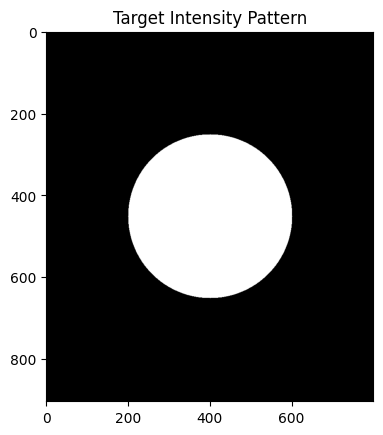

In [48]:
# Test pattern: A simple circular aperture
H, W = 2714 // 3, 1600 // 2

# Create a circular aperture in the center of the target plane
Y, X = torch.meshgrid(torch.arange(H), torch.arange(W), indexing='ij')
center_y, center_x = H // 2, W // 2
radius = min(H, W) // 4
Target = ((X - center_x)**2 + (Y - center_y)**2) <= radius**2
Target = Target.float()
Target = Target.to('cuda' if torch.cuda.is_available() else 'cpu')  # Move to GPU if available

# Show
plt.imshow(Target.cpu().numpy(), cmap='gray')
plt.title("Target Intensity Pattern")
plt.show()



Iteration 1/100, MSE: 0.000000
Iteration 10/100, MSE: 0.000000
Iteration 20/100, MSE: 0.000000
Iteration 30/100, MSE: 0.000000
Iteration 40/100, MSE: 0.000000
Iteration 50/100, MSE: 0.000000
Iteration 60/100, MSE: 0.000000
Iteration 70/100, MSE: 0.000000
Iteration 80/100, MSE: 0.000000
Iteration 90/100, MSE: 0.000000
Iteration 100/100, MSE: 0.000000


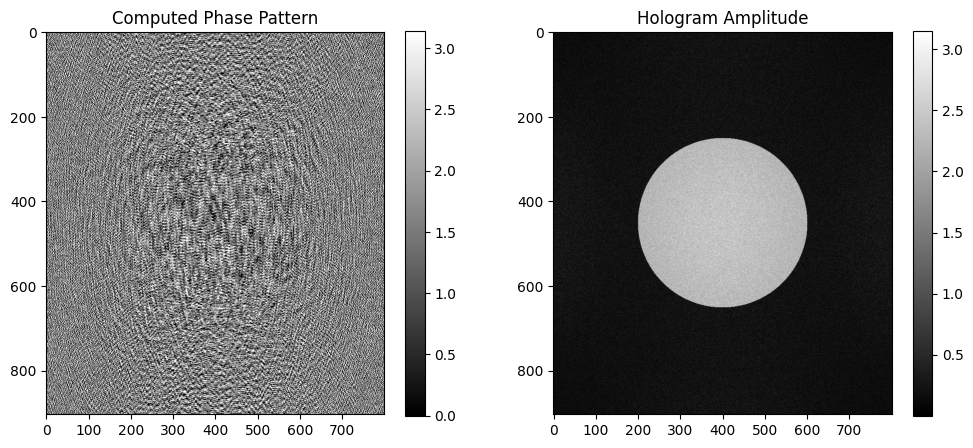

In [49]:
# Perform GS algorithm
distance = 0.36  # Propagation distance in meters
num_iterations = 100
phase, hologram = GS_algorithm(Target, distance, num_iterations)

# Visualize the results
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(phase.cpu().numpy(), cmap='gray')
plt.title("Computed Phase Pattern")
plt.colorbar()
plt.subplot(1, 2, 2)
plt.imshow(torch.abs(hologram).cpu().numpy(), cmap='gray')
plt.title("Hologram Amplitude")
plt.colorbar()
plt.show()


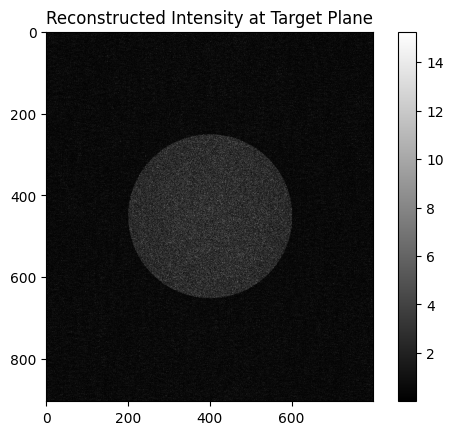

In [50]:
# Propagate the phase pattern
reconstructed_field, _ = torch_propagate(
    torch.exp(1j * phase),
    z=distance,
    Height=800 * 10.8e-6,
    Width=1358 * 10.8e-6,
    PixelH=H,
    PixelW=W,
    Lambda=1550e-9
)

# Visualize the reconstructed intensity
plt.imshow(torch.abs(reconstructed_field).cpu().numpy()**2, cmap='gray')
plt.title("Reconstructed Intensity at Target Plane")
plt.colorbar()
plt.show()


In [ ]:
#  Quantization Function
def Quantization (Input : torch.Tensor):
    # Input is a phase pattern in radians between
    # 0 and 2pi

    # Displacement based on odd or even (%)
    odd_displacement = np.array([
        0.0,
        1.27,
        2.93,
        6.62,
        5.22,
        6.75,
        8.54,
        12.61,
        14.27,
        18.34,
        21.66,
        28.03,
        25.61,
        29.68,
        32.99,
        39.62,
        37.71,
        41.02,
        45.10,
        51.08,
        49.30,
        52.61,
        56.82,
        63.06,
        61.27,
        66.75,
        73.38,
        82.29,
        78.47,
        83.69,
        90.45,
        100.0
    ])

    even_displacement = np.array([
        0.64,
        1.53,
        2.80,
        5.99,
        6.11,
        7.26,
        8.66,
        12.23,
        14.14,
        17.71,
        20.76,
        26.75,
        25.73,
        29.30,
        32.36,
        38.47,
        39.11,
        41.78,
        45.86,
        51.21,
        51.34,
        54.14,
        58.09,
        63.57,
        62.55,
        67.13,
        73.50,
        81.27,
        80.38,
        84.46,
        90.57,
        98.22
    ])

    odd_displacement = torch.from_numpy(odd_displacement).to(Input.device)
    odd_displacement = odd_displacement / 100 * 2 * np.pi  # Scale to radians

    even_displacement = torch.from_numpy(even_displacement).to(Input.device)
    even_displacement = even_displacement / 100 * 2 * np.pi  # Scale to radians

    # Create a quantized output tensor (to store indices)
    Quantized = torch.zeros_like(Input, dtype=torch.long)

    # Apply quantization based on column eveness - return indices
    for col in range(Input.shape[1]):
        if col % 2 == 0:
            Quantized[:, col] = torch.argmin(torch.abs(Input[:, col].unsqueeze(1) - even_displacement), dim=1)
        else:
            Quantized[:, col] = torch.argmin(torch.abs(Input[:, col].unsqueeze(1) - odd_displacement), dim=1)

    return Quantized


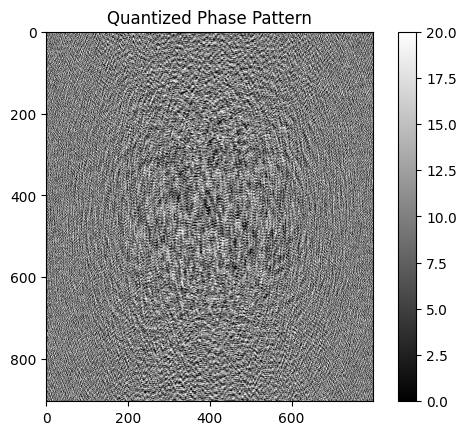

In [55]:
# Quantize the computed phase pattern
quantized_phase = Quantization(phase)

# Visualize the quantized phase pattern
plt.imshow(quantized_phase.cpu().numpy(), cmap='gray')
plt.title("Quantized Phase Pattern")
plt.colorbar()
plt.show()

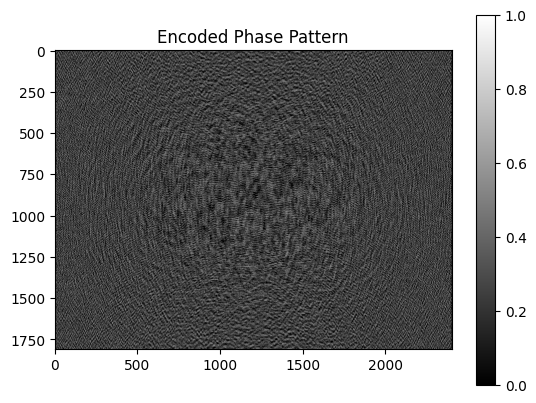

In [ ]:
encoder = Encode_NIR()
encoded_phase = encoder.encode(quantized_phase.view(1, phase.shape[0], phase.shape[1]).to('cpu'))

plt.imshow(encoded_phase.cpu().numpy(), cmap='gray')
plt.title("Encoded Phase Pattern")
plt.colorbar()
plt.show()

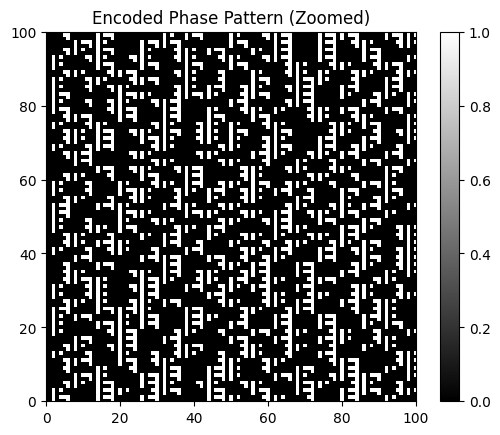

In [60]:
# Visualize the encoded phase pattern (Zoom in to see the blocks)
plt.imshow(encoded_phase.cpu().numpy(), cmap='gray')
plt.title("Encoded Phase Pattern (Zoomed)")
plt.xlim(0, 100)  # Zoom in on the first 100 columns
plt.ylim(0, 100)  # Zoom in on the first 100 rows
plt.colorbar()
plt.show()